# EMA Affect Modelling â€” Proof of Concept

Model **EM_PA**, **EM_NA** (bounded [0, 1]) and **EM_BO** (binary 0/1) from ecological momentary
assessment data using the vaelong VAE framework.

**Features:**
- EM_PA, EM_NA: bounded outcome variables
- EM_BO: binary outcome variable
- sin_hrs, cos_hrs: continuous time-varying features
- AGE, SEX_1, SEX_2, SEX_3: baseline covariates

**Models:**
- Dense VAE with EM imputation + hyperparameter tuning
- Linear Mixed Model (benchmark)

In [1]:
import warnings
import itertools
import copy

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, log_loss
from torch.utils.data import DataLoader

from vaelong import (
    VariableConfig, VariableSpec,
    LongitudinalVAE,
    VAETrainer, LongitudinalDataset,
    create_missing_mask,
)

torch.manual_seed(42)
np.random.seed(42)

## 1. Load and reshape data

In [2]:
df = pd.read_parquet("W:/parquetdata/Final_DF.parquet")
df = df.sort_values(["id", "hrs_since_start"]).reset_index(drop=True)

subject_ids = sorted(df["id"].unique())
n_subjects = len(subject_ids)
seq_len = 105

outcome_cols = ["EM_PA", "EM_NA", "EM_BO"]
time_cols = ["sin_hrs", "cos_hrs"]
feature_cols = outcome_cols + time_cols
n_features = len(feature_cols)

baseline_cols = ["AGE", "SEX_1", "SEX_2", "SEX_3"]
n_baseline = len(baseline_cols)

print(f"Subjects: {n_subjects}, Sequence length: {seq_len}")
print(f"Features: {feature_cols}")
print(f"Baseline: {baseline_cols}")

Subjects: 1174, Sequence length: 105
Features: ['EM_PA', 'EM_NA', 'EM_BO', 'sin_hrs', 'cos_hrs']
Baseline: ['AGE', 'SEX_1', 'SEX_2', 'SEX_3']


## 2. Build 3D arrays

In [3]:
data = np.zeros((n_subjects, seq_len, n_features), dtype=np.float32)
mask = np.ones((n_subjects, seq_len, n_features), dtype=np.float32)
baseline = np.zeros((n_subjects, n_baseline), dtype=np.float32)

id_to_idx = {sid: i for i, sid in enumerate(subject_ids)}

for sid, grp in df.groupby("id"):
    i = id_to_idx[sid]
    grp = grp.sort_values("hrs_since_start").reset_index(drop=True)

    for j, col in enumerate(feature_cols):
        vals = grp[col].values
        data[i, :, j] = np.nan_to_num(vals, nan=0.0)
        mask[i, :, j] = (~np.isnan(vals)).astype(np.float32)

    baseline[i] = grp[baseline_cols].iloc[0].values

# sin_hrs, cos_hrs are always observed
for j, col in enumerate(feature_cols):
    if col in time_cols:
        mask[:, :, j] = 1.0

observed_rate = mask[:, :, :len(outcome_cols)].mean()
print(f"Observed rate (outcomes): {observed_rate:.1%}")
print(f"Data shape:     {data.shape}")
print(f"Baseline shape: {baseline.shape}")

Observed rate (outcomes): 39.3%
Data shape:     (1174, 105, 5)
Baseline shape: (1174, 4)


## 3. Variable configuration and dataset

In [4]:
var_config = VariableConfig(variables=[
    VariableSpec(name="EM_PA",    var_type="bounded", lower=0.0, upper=1.0),
    VariableSpec(name="EM_NA",    var_type="bounded", lower=0.0, upper=1.0),
    VariableSpec(name="EM_BO",    var_type="binary"),
    VariableSpec(name="sin_hrs",  var_type="continuous"),
    VariableSpec(name="cos_hrs",  var_type="continuous"),
])

dataset = LongitudinalDataset(
    data, mask=mask, var_config=var_config,
    baseline_covariates=baseline, normalize=True,
)

train_size = int(0.8 * n_subjects)
val_size = n_subjects - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Train: {train_size}, Validation: {val_size}")
print(f"Bounded indices: {var_config.bounded_indices}")
print(f"Binary indices:  {var_config.binary_indices}")

Train: 939, Validation: 235
Bounded indices: [0, 1]
Binary indices:  [2]


## 4. Hyperparameter tuning

In [5]:
hp_grid = {
    "learning_rate": [1e-4, 5e-4, 1e-3],
    "weight_decay": [0.0, 1e-4, 1e-3],
}

hp_combos = list(itertools.product(hp_grid["learning_rate"], hp_grid["weight_decay"]))
print(f"Tuning over {len(hp_combos)} hyperparameter combinations...\n")

best_val_loss = float("inf")
best_hp = None
tuning_results = []

for lr, wd in hp_combos:
    torch.manual_seed(42)
    np.random.seed(42)

    m = LongitudinalVAE(
        input_dim=var_config.n_features,
        hidden_dim=64,
        latent_dim=16,
        seq_len=seq_len,
        n_baseline=n_baseline,
        var_config=var_config,
    )
    t = VAETrainer(m, learning_rate=lr, beta=0.5, var_config=var_config,
                   weight_decay=wd)

    h = t.fit(
        train_loader, val_loader=val_loader, epochs=200, verbose=False,
        use_em_imputation=True, em_iterations=2, patience=20,
    )

    final_val = min(h["val_loss"])
    tuning_results.append({"lr": lr, "weight_decay": wd, "best_val_loss": final_val})
    print(f"  lr={lr:.0e}, wd={wd:.0e}  â†’  best val loss = {final_val:.4f}")

    if final_val < best_val_loss:
        best_val_loss = final_val
        best_hp = {"learning_rate": lr, "weight_decay": wd}

tuning_df = pd.DataFrame(tuning_results)
print(f"\nBest: lr={best_hp['learning_rate']:.0e}, "
      f"weight_decay={best_hp['weight_decay']:.0e} "
      f"(val loss = {best_val_loss:.4f})")

Tuning over 9 hyperparameter combinations...

  lr=1e-04, wd=0e+00  â†’  best val loss = 1462.3394
  lr=1e-04, wd=1e-04  â†’  best val loss = 1463.1963
  lr=1e-04, wd=1e-03  â†’  best val loss = 1465.0346
  lr=5e-04, wd=0e+00  â†’  best val loss = -928.6465
  lr=5e-04, wd=1e-04  â†’  best val loss = -956.8303
  lr=5e-04, wd=1e-03  â†’  best val loss = -951.5216
  lr=1e-03, wd=0e+00  â†’  best val loss = -921.7499
  lr=1e-03, wd=1e-04  â†’  best val loss = -936.0372
  lr=1e-03, wd=1e-03  â†’  best val loss = -924.2928

Best: lr=5e-04, weight_decay=1e-04 (val loss = -956.8303)


## 4b. Tuning results + retrain with best hyperparameters

In [6]:
# Show tuning grid
pivot = tuning_df.pivot(index="lr", columns="weight_decay", values="best_val_loss")
print("Validation loss grid (lr Ã— weight_decay):")
print(pivot.to_string(float_format="{:.4f}".format))

# Retrain final model with best HP
torch.manual_seed(42)
np.random.seed(42)

model = LongitudinalVAE(
    input_dim=var_config.n_features,
    hidden_dim=64,
    latent_dim=16,
    seq_len=seq_len,
    n_baseline=n_baseline,
    var_config=var_config,
)

trainer = VAETrainer(model, learning_rate=best_hp["learning_rate"], beta=0.5,
                     var_config=var_config, weight_decay=best_hp["weight_decay"])

history = trainer.fit(
    train_loader, val_loader=val_loader, epochs=200, verbose=True,
    use_em_imputation=True, em_iterations=2, patience=20,
)

Validation loss grid (lr Ã— weight_decay):
weight_decay    0.0000    0.0001    0.0010
lr                                        
0.0001       1462.3394 1463.1963 1465.0346
0.0005       -928.6465 -956.8303 -951.5216
0.0010       -921.7499 -936.0372 -924.2928
Epoch [10/200] Train Loss: 4278.0604 (Recon: 4210.9912, KLD: 134.1384) | Val Loss: 3994.4772
Epoch [20/200] Train Loss: 3298.3077 (Recon: 3254.2751, KLD: 88.0651) | Val Loss: 3080.7711
Epoch [30/200] Train Loss: 2344.2359 (Recon: 2283.0612, KLD: 122.3495) | Val Loss: 2230.4228
Epoch [40/200] Train Loss: 1565.8062 (Recon: 1500.8699, KLD: 129.8726) | Val Loss: 1508.9618
Epoch [50/200] Train Loss: 863.9013 (Recon: 788.4519, KLD: 150.8990) | Val Loss: 871.7469
Epoch [60/200] Train Loss: 224.5034 (Recon: 142.9802, KLD: 163.0464) | Val Loss: 314.8650
Epoch [70/200] Train Loss: -290.6994 (Recon: -373.8124, KLD: 166.2259) | Val Loss: -127.1441
Epoch [80/200] Train Loss: -695.9556 (Recon: -781.3426, KLD: 170.7740) | Val Loss: -468.1412
Epoch

## 5. Training curves and landmark prediction

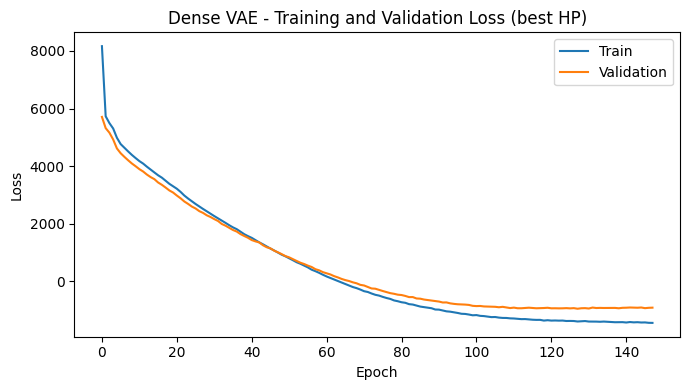

Validation subjects: 235
Landmark time: 52
Future observed rate: 29.2%


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["train_loss"], label="Train")
ax.plot(history["val_loss"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Dense VAE - Training and Validation Loss (best HP)")
ax.legend()
plt.tight_layout()
plt.show()

# --- Landmark prediction ---
landmark_t = seq_len // 2

val_indices = list(val_ds.indices)
all_actual, all_predicted = [], []

for idx in val_indices:
    xi = dataset[idx][0].unsqueeze(0)
    mi = dataset[idx][1].unsqueeze(0)
    bi = dataset[idx][3].unsqueeze(0)

    xi_obs = xi[:, :landmark_t, :]
    mi_obs = mi[:, :landmark_t, :]

    pred_i = model.predict_from_landmark(
        xi_obs, mi_obs, total_seq_len=seq_len, baseline=bi,
    )

    all_actual.append(dataset.inverse_transform(xi).detach())
    all_predicted.append(dataset.inverse_transform(pred_i).detach())

all_actual = torch.cat(all_actual, dim=0).numpy()
all_predicted = torch.cat(all_predicted, dim=0).numpy()

future_actual = all_actual[:, landmark_t:, :]
future_pred = all_predicted[:, landmark_t:, :]

# Build mask for validation subjects (original mask, not normalised)
val_mask = mask[val_indices, :, :]
future_mask = val_mask[:, landmark_t:, :]

print(f"Validation subjects: {len(val_indices)}")
print(f"Landmark time: {landmark_t}")
print(f"Future observed rate: {future_mask[:, :, :len(outcome_cols)].mean():.1%}")

## 6. Landmark prediction plots

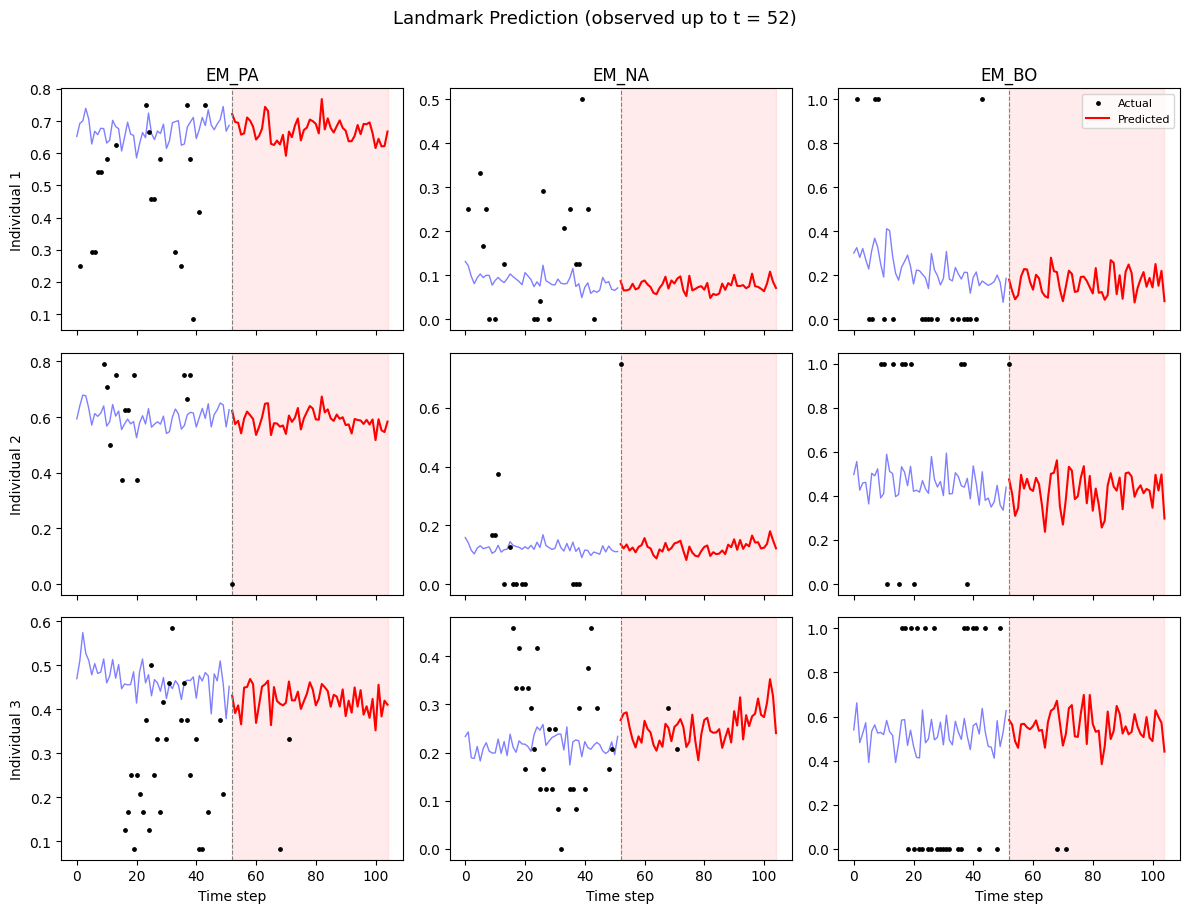

In [8]:
rng = np.random.default_rng(123)
chosen = sorted(rng.choice(len(val_indices), size=3, replace=False))
time_axis = np.arange(seq_len)

n_outcomes = len(outcome_cols)
fig, axes = plt.subplots(3, n_outcomes, figsize=(4 * n_outcomes, 9), sharex=True)

for row, c in enumerate(chosen):
    for col, vname in enumerate(outcome_cols):
        ax = axes[row, col]
        vidx = feature_cols.index(vname)

        actual_vals = all_actual[c, :, vidx]
        pred_vals = all_predicted[c, :, vidx]
        obs_mask_c = val_mask[c, :, vidx].astype(bool)

        # Only plot actual where observed (scatter to avoid joining gaps)
        ax.scatter(time_axis[obs_mask_c], actual_vals[obs_mask_c],
                   c="k", s=6, zorder=3, label="Actual")
        ax.plot(time_axis[:landmark_t], pred_vals[:landmark_t],
                "b-", linewidth=1, alpha=0.5)
        ax.plot(time_axis[landmark_t:], pred_vals[landmark_t:],
                "r-", linewidth=1.5, label="Predicted")

        ax.axvspan(landmark_t, seq_len - 1, alpha=0.08, color="red")
        ax.axvline(landmark_t, color="grey", linestyle="--", linewidth=0.8)

        if row == 0:
            ax.set_title(vname, fontsize=12)
        if col == 0:
            ax.set_ylabel(f"Individual {row + 1}", fontsize=10)
        if row == 2:
            ax.set_xlabel("Time step")

axes[0, -1].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Landmark Prediction (observed up to t = {landmark_t})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. LMM benchmark

In [9]:
train_indices = list(train_ds.indices)
n_val = len(val_indices)

lmm_predictions = np.zeros((n_val, seq_len, n_features))

for col_idx, vname in enumerate(outcome_cols):
    print(f"  Fitting LMM for {vname}...", end=" ", flush=True)

    rows = []
    for i in train_indices:
        for t in range(landmark_t):
            if mask[i, t, col_idx] == 1.0:
                row = {
                    "subject": int(i), "time": t,
                    "y": float(data[i, t, col_idx]),
                    "sin_hrs": float(data[i, t, feature_cols.index("sin_hrs")]),
                    "cos_hrs": float(data[i, t, feature_cols.index("cos_hrs")]),
                }
                for b, bcol in enumerate(baseline_cols):
                    row[bcol] = float(baseline[i, b])
                rows.append(row)

    df_train = pd.DataFrame(rows)

    fixed_formula = "y ~ time + sin_hrs + cos_hrs + " + " + ".join(baseline_cols)
    re_formula = "1 + time"

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = smf.mixedlm(fixed_formula, df_train, groups=df_train["subject"],
                         re_formula=re_formula)
        mdf = md.fit(reml=True, method="lbfgs")

    beta_hat = np.array(mdf.fe_params)
    D = np.array(mdf.cov_re)
    sigma2_e = mdf.scale
    print(f"done (var_e={sigma2_e:.4f})")

    for j, subj_idx in enumerate(val_indices):
        obs_times, obs_y, obs_sin, obs_cos = [], [], [], []
        for t in range(landmark_t):
            if mask[subj_idx, t, col_idx] == 1.0:
                obs_times.append(t)
                obs_y.append(data[subj_idx, t, col_idx])
                obs_sin.append(data[subj_idx, t, feature_cols.index("sin_hrs")])
                obs_cos.append(data[subj_idx, t, feature_cols.index("cos_hrs")])

        bl_vals = [baseline[subj_idx, b] for b in range(n_baseline)]

        if len(obs_times) == 0:
            for t in range(seq_len):
                sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
                cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
                x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
                lmm_predictions[j, t, col_idx] = x_t @ beta_hat
            continue

        obs_times_arr = np.array(obs_times, dtype=float)
        obs_y_arr = np.array(obs_y)
        n_obs = len(obs_times)

        X_obs = np.column_stack([
            np.ones(n_obs), obs_times_arr,
            np.array(obs_sin), np.array(obs_cos),
            np.tile(bl_vals, (n_obs, 1)),
        ])
        Z_obs = np.column_stack([np.ones(n_obs), obs_times_arr])

        r = obs_y_arr - X_obs @ beta_hat
        V = Z_obs @ D @ Z_obs.T + sigma2_e * np.eye(n_obs) + 1e-6 * np.eye(n_obs)
        u_hat = D @ Z_obs.T @ np.linalg.solve(V, r)

        for t in range(seq_len):
            sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
            cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
            x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
            z_t = np.array([1.0, t])
            lmm_predictions[j, t, col_idx] = x_t @ beta_hat + z_t @ u_hat

    # Clip predictions to [0, 1]
    lmm_predictions[:, :, col_idx] = np.clip(lmm_predictions[:, :, col_idx], 0, 1)

  Fitting LMM for EM_PA... done (var_e=0.0229)
  Fitting LMM for EM_NA... done (var_e=0.0149)
  Fitting LMM for EM_BO... done (var_e=0.1415)


## 8. Model comparison

In [10]:
lmm_future = lmm_predictions[:, landmark_t:, :]

eps_ll = 1e-7

results = []

for col_idx, vname in enumerate(outcome_cols):
    a = future_actual[:, :, col_idx].ravel()
    valid = future_mask[:, :, col_idx].ravel().astype(bool)  # use real mask
    is_binary = (vname == "EM_BO")

    for model_name, preds in [("VAE", future_pred), ("LMM", lmm_future)]:
        p = preds[:, :, col_idx].ravel()
        rmse = np.sqrt(np.mean((a[valid] - p[valid]) ** 2))
        corr = np.corrcoef(a[valid], p[valid])[0, 1] if np.nanstd(a[valid]) > 0 else float("nan")

        row = {"Variable": vname, "Model": model_name,
               "RMSE": rmse, "Corr": corr}

        if is_binary:
            p_clip = np.clip(p[valid], eps_ll, 1 - eps_ll)
            row["LogLik"] = -log_loss(a[valid], p_clip)
            row["AUC"] = roc_auc_score(a[valid], p[valid])
        else:
            sigma = rmse
            row["LogLik"] = (-0.5 * np.mean(((a[valid] - p[valid]) / max(sigma, eps_ll)) ** 2)
                            - np.log(max(sigma, eps_ll)) - 0.5 * np.log(2 * np.pi))

        results.append(row)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\nBest HP: lr={best_hp['learning_rate']:.0e}, weight_decay={best_hp['weight_decay']:.0e}")

Variable Model   RMSE   Corr  LogLik    AUC
   EM_PA   VAE 0.2308 0.4885  0.0471    NaN
   EM_PA   LMM 0.2036 0.6467  0.1725    NaN
   EM_NA   VAE 0.1506 0.5703  0.4741    NaN
   EM_NA   LMM 0.1517 0.5763  0.4670    NaN
   EM_BO   VAE 0.3841 0.5358 -0.4592 0.8222
   EM_BO   LMM 0.3814 0.5465 -0.8731 0.8186

Best HP: lr=5e-04, weight_decay=1e-04


## 9. Comparison plot

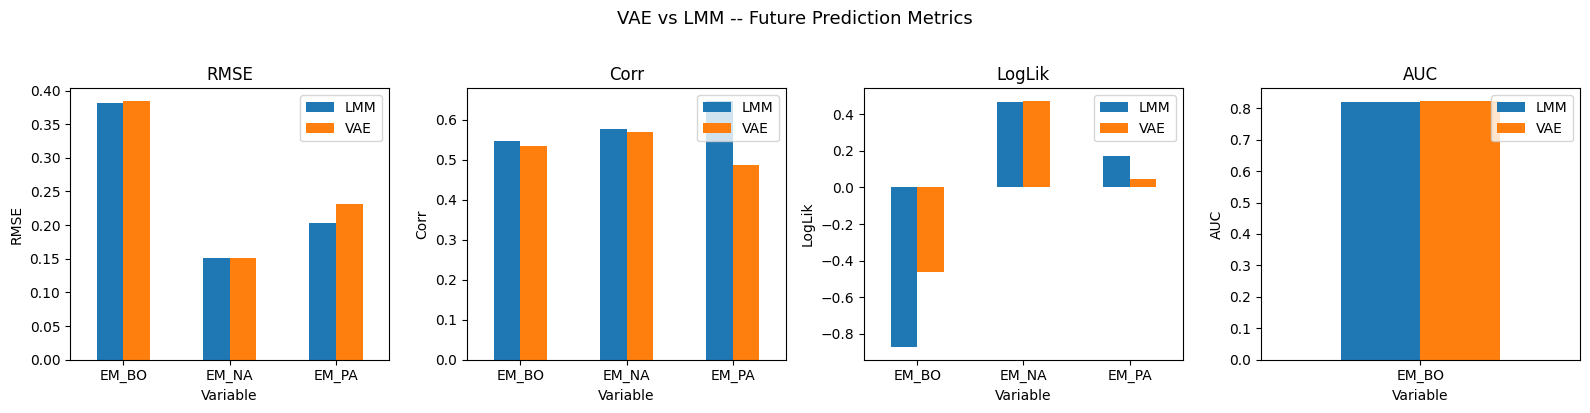

In [11]:
metrics = ["RMSE", "Corr", "LogLik"]
if "AUC" in results_df.columns:
    metrics.append("AUC")

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))

for ax, metric in zip(axes, metrics):
    sub = results_df.dropna(subset=[metric])
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    pivot = sub.pivot(index="Variable", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(title="")

fig.suptitle("VAE vs LMM -- Future Prediction Metrics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()